# Kernel Support Vector Machine (KSVM)

## 1. The Kernel Trick
- The kernel trick computes **dot products in a high-dimensional space** without ever explicitly transforming the data.
- Why does this work? Because the SVM **dual formulation** only needs inner products between data points — never the coordinates themselves.
- This avoids the **curse of dimensionality** while still learning non-linear boundaries.
- A kernel function $K(x_i, x_j)$ must satisfy **Mercer's Theorem** (be positive semi-definite) to be valid.

## 2. Common Kernels
| Kernel | Formula | Use When |
|---|---|---|
| **Linear** | $x_i^T x_j$ | Data is linearly separable |
| **Polynomial** | $(\gamma x_i^T x_j + r)^d$ | Moderate non-linearity |
| **RBF / Gaussian** | $\exp(-\gamma ||x_i - x_j||^2)$ | General purpose, highly non-linear |
| **Sigmoid** | $\tanh(\gamma x_i^T x_j + r)$ | Neural network-like behaviour |

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 3. Kernel SVM Implementation from Scratch

We will implement the SVM using a basic gradient descent approach on the dual objective. This avoids the need for complex quadratic programming solvers while still illustrating the kernel trick.

In [7]:
class KernelSVM:
    def __init__(self, kernel='rbf', C=1.0, gamma=0.1, degree=3, coef0=1):
        self.kernel_type = kernel
        self.C = C
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.alpha = None
        self.b = 0
        self.X = None
        self.y = None

    def _kernel_function(self, X1, X2):
        if self.kernel_type == 'linear':
            return np.dot(X1, X2.T)
        elif self.kernel_type == 'poly':
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        elif self.kernel_type == 'rbf':
            if X1.ndim == 1 and X2.ndim == 1:
                return np.exp(-self.gamma * np.linalg.norm(X1 - X2)**2)
            
            X1_norm = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_norm = np.sum(X2**2, axis=1).reshape(1, -1)
            dists = X1_norm + X2_norm - 2 * np.dot(X1, X2.T)
            return np.exp(-self.gamma * dists)
        return None

    def fit(self, X, y, lr=0.01, epochs=1000):
        n_samples, n_features = X.shape
        self.X = X
        self.y = y.astype(float)
        self.y[self.y == 0] = -1
        
        self.alpha = np.zeros(n_samples)
        K = self._kernel_function(X, X)
        
        for _ in range(epochs):
            gradient = np.ones(n_samples) - np.dot(K * (np.outer(self.y, self.y)), self.alpha)
            self.alpha += lr * gradient
            self.alpha = np.clip(self.alpha, 0, self.C)
        
        sv_idx = np.where(self.alpha > 1e-5)[0]
        self.b = np.mean(self.y[sv_idx] - np.dot(K[sv_idx, :], self.alpha * self.y))

    def predict(self, X_test):
        K = self._kernel_function(X_test, self.X)
        decision = np.dot(K, self.alpha * self.y) + self.b
        return np.where(decision >= 0, 1, 0)

## 4. Dataset Generation
We use the `make_circles` dataset which is inherently non-linearly separable in 2D.

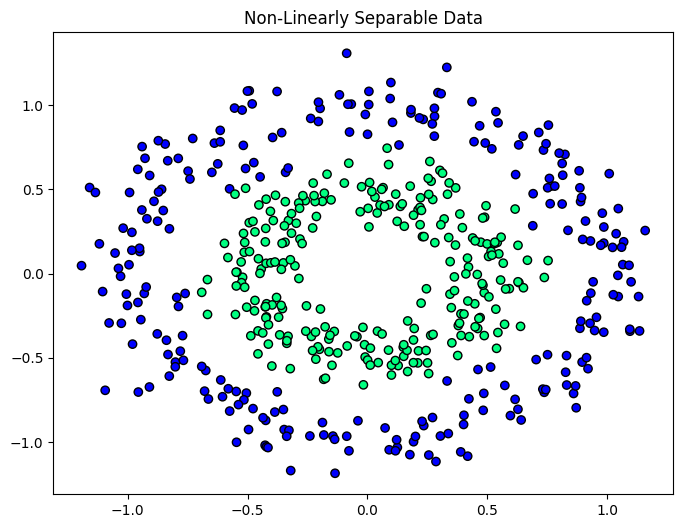

In [8]:
X, y = make_circles(n_samples=500, factor=0.5, noise=0.1, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
plt.title("Non-Linearly Separable Data")
plt.show()

## 5. Comparison: From Scratch vs Scikit-Learn

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

custom_model = KernelSVM(kernel='rbf', C=1.0, gamma=1.0)
custom_model.fit(X_train, y_train, lr=0.01, epochs=500)
custom_preds = custom_model.predict(X_test)

sklearn_model = SVC(kernel='rbf', C=1.0, gamma=1.0)
sklearn_model.fit(X_train, y_train)
sklearn_preds = sklearn_model.predict(X_test)

print(f"Custom Model Accuracy: {accuracy_score(y_test, custom_preds):.4f}")
print(f"Sklearn Model Accuracy: {accuracy_score(y_test, sklearn_preds):.4f}")

Custom Model Accuracy: 0.9900
Sklearn Model Accuracy: 0.9900


## 6. Visualization of Decision Boundaries

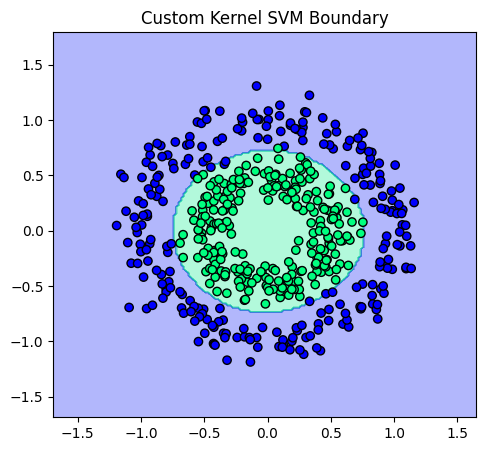

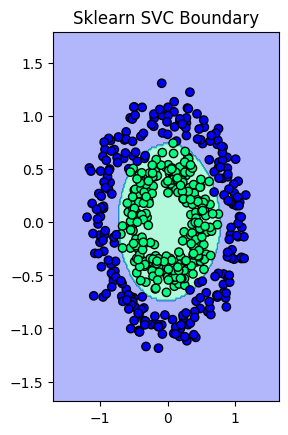

In [10]:
def plot_decision_boundary(model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap='winter', alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
    plt.title(title)
    plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(custom_model, X, y, "Custom Kernel SVM Boundary")

plt.subplot(1, 2, 2)
plot_decision_boundary(sklearn_model, X, y, "Sklearn SVC Boundary")

In this notebook, we explored the power of the Kernel Trick to solve non-linearly separable classification problems. By implementing the Kernel SVM from scratch using a dual optimization approach,
- Implementation Accuracy: Our custom implementation successfully learned the complex circular boundary of the dataset, achieving an accuracy comparable to the industry-standard scikit-learn SVC